# A Minimal NDT Training Setup on Perich & Miller 2018

<html>
<img src="https://camo.githubusercontent.com/38004ff525c31b5088bbac056320ce63b4caaf23d8d0d5aea30b8cf7deba7b73/68747470733a2f2f746f7263682d627261696e2e72656164746865646f63732e696f2f656e2f6c61746573742f5f7374617469632f746f7263685f627261696e5f6c6f676f2e706e67", width="100px">
</html>


This example walks through a minimal training pipeline for decoding 2D cursor velocity from motor cortex spiking activity, using a center-out reaching recording from the [Perich & Miller 2018](https://doi.org/10.1016/j.neuron.2018.08.037) dataset.

It is intended as a starting point for new users of `torch_brain` and `brainsets`, and shows how to:
1. Build a custom `Dataset` on top of a `brainsets` recording.
2. Sample fixed-length windows from continuous recordings using `RandomFixedWindowSampler` and `SequentialFixedWindowSampler`.
3. Train an NDT (Neural Data Transformer) decoder.


> ⚠ **Note:**
> Although this notebook will run on a CPU, it is recommended that you use a GPU runtime.
> If you're on Google Colab, do: Runtime > Change runtime type > T4 GPU


## Setup

Install dependencies:


In [ ]:
!pip install scikit-learn matplotlib torch git+https://github.com/neuro-galaxy/torch_brain

And preprocess the dataset using `brainsets`:


In [ ]:
!brainsets prepare perich_miller_population_2018 --raw-dir data/raw --processed-dir data/processed

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


/home/aandre1/ws/torch_brain/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparameters


In [13]:
# Hyperparameters (feel free to play with these)
BIN_SIZE = 0.01  # seconds per spike-count bin
WINDOW_LENGTH = 1.0  # seconds of context fed to the model
BATCH_SIZE = 32
EPOCHS = 100
LR = 1e-3

## Defining a Simple & Custom Dataset

`brainsets` provides a `PerichMillerPopulation2018` base class that handles file I/O for this recording.

We subclass it and define two things on top:
- **`get_sampling_intervals`**: Returns the time windows the sampler may draw from, intersected with the spike domain and the appropriate train/validation split.
- **`__getitem__`**: Given a sampled time window (a `DatasetIndex`), turns it into model-compatible tensors.


In [ ]:
from torch_brain.datasets import DatasetIndex, PerichMillerPopulation2018
from torch_brain.utils import bin_spikes


class SimplePerichMillerPopulationDataset(PerichMillerPopulation2018):
    def __init__(self, root: str, split: str, bin_size: float):
        super().__init__(root=root, recording_ids=["c_20131003_center_out_reaching"])
        assert split in ("train", "valid")

        self.split = split
        self.bin_size = bin_size
        self.num_units = len(self.get_unit_ids())

    # Contract between Datasets and Samplers:
    # get_sampling_intervals() returns {recording_id: Interval} listing
    # the windows the sampler may draw from.
    def get_sampling_intervals(self, *_args, **_kwargs):
        intervals = super().get_sampling_intervals()

        for rid, interval in intervals.items():
            recording = self.get_recording(rid)

            spikes_domain = recording.spikes.domain
            split_domain = recording.get_nested_attribute(f"{self.split}_domain")

            intervals[rid] = interval & spikes_domain & split_domain

        return intervals

    # `index` is a DatasetIndex(recording_id, start, end) produced by the sampler.
    def __getitem__(self, index: DatasetIndex):
        data = super().__getitem__(index)

        # Spikes are an irregular event stream — bin them into a regular grid.
        X = bin_spikes(
            data.spikes, num_units=len(data.units), bin_size=self.bin_size, eps=1e-1
        )
        X = torch.from_numpy(X).float()  # shape: (num_bins, num_units)

        # Cursor velocity is a regularly-sampled signal; divide to normalize.
        Y = data.cursor.vel / 20.0
        Y = torch.from_numpy(Y).float()  # shape: (out_samples, 2)
        return X, Y

## Creating the Datasets, Samplers, and DataLoaders

💡 The main pattern for data pipelines in `torch_brain`:
- **Dataset** tells the sampler *where sampling is allowed*,
- **Sampler** decides *what* samples to load (by emitting `DatasetIndex` objects), and
- **DataLoader** batches the samples as usual.

For continuous recordings (no natural trial boundaries), `RandomFixedWindowSampler` draws random windows of a fixed length during training, while `SequentialFixedWindowSampler` tiles the validation data non-overlappingly.


In [15]:
from torch.utils.data import DataLoader

from torch_brain.samplers import RandomFixedWindowSampler, SequentialFixedWindowSampler

DATA_ROOT = "../../../../data/processed"

train_ds = SimplePerichMillerPopulationDataset(
    DATA_ROOT, split="train", bin_size=BIN_SIZE
)
train_sampler = RandomFixedWindowSampler(
    sampling_intervals=train_ds.get_sampling_intervals(),
    window_length=WINDOW_LENGTH,
    drop_short=True,
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler)

val_ds = SimplePerichMillerPopulationDataset(
    DATA_ROOT, split="valid", bin_size=BIN_SIZE
)
val_sampler = SequentialFixedWindowSampler(
    sampling_intervals=val_ds.get_sampling_intervals(),
    window_length=WINDOW_LENGTH,
    drop_short=True,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, sampler=val_sampler)

print(f"Number of units:     {train_ds.num_units}")
print(f"Training windows:    {len(train_sampler)}")
print(f"Validation windows:  {len(val_sampler)}")

Number of units:     71
Training windows:    417
Validation windows:  60


Let's peek at a single sample to confirm the shapes match what we expect, and visualize the binned spikes (input) and cursor velocity (target) for one window.


First sample:
    recording_id: c_20131003_center_out_reaching
    start: 249.766 s,  end: 250.766 s

X shape: (100, 71)  (num_bins, num_units)
Y shape: (100, 2)  (out_samples, 2)


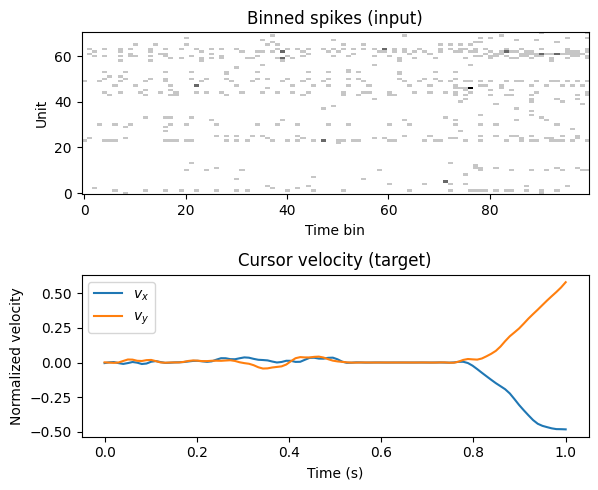

In [16]:
first_index = next(iter(train_sampler))
print(
    f"First sample:\n"
    f"    recording_id: {first_index.recording_id}\n"
    f"    start: {first_index.start:.3f} s,  end: {first_index.end:.3f} s\n"
)

X, Y = train_ds[first_index]
print(f"X shape: {tuple(X.shape)}  (num_bins, num_units)")
print(f"Y shape: {tuple(Y.shape)}  (out_samples, 2)")

fig, axes = plt.subplots(2, 1, figsize=(6, 5))

axes[0].imshow(
    X.T.numpy(), aspect="auto", cmap="Greys", origin="lower", interpolation="nearest"
)
axes[0].set_title("Binned spikes (input)")
axes[0].set_xlabel("Time bin")
axes[0].set_ylabel("Unit")

t = np.linspace(0, WINDOW_LENGTH, Y.shape[0])
axes[1].plot(t, Y[:, 0].numpy(), label="$v_x$")
axes[1].plot(t, Y[:, 1].numpy(), label="$v_y$")
axes[1].set_title("Cursor velocity (target)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Normalized velocity")
axes[1].legend()

plt.tight_layout()
plt.show()

## The Model

NDT (Neural Data Transformer) is a small transformer encoder that operates on binned spike trains.

It maps `(batch, num_bins, num_units)` → `(batch, num_bins, output_dim)` via:
1. A linear projection (`in_stitch`) from `num_units` → `hidden_dim`,
2. Learned positional embeddings added to the projected spikes,
3. A standard transformer encoder, and
4. A per-timestep linear readout (`out_stitch`).


In [17]:
class NDT(nn.Module):
    def __init__(
        self,
        hidden_dim: int,
        encoder_num_heads: int,
        encoder_ffn_factor: int,
        encoder_num_layers: int,
        dropout: float,
        num_units: int,
        ctx_window: float,
        bin_size: float,
        output_dim: int,
    ):
        super().__init__()

        num_bins = int(ctx_window / bin_size)
        self.position_emb = nn.Embedding(num_bins, hidden_dim)
        self.in_stitch = nn.Linear(num_units, hidden_dim, bias=False)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=encoder_num_heads,
            dim_feedforward=hidden_dim * encoder_ffn_factor,
            dropout=dropout,
            activation=nn.ReLU(),
            norm_first=True,
            batch_first=True,
        )
        self.encoder = nn.Sequential(
            nn.Dropout(dropout),
            nn.TransformerEncoder(
                encoder_layer=encoder_layer,
                num_layers=encoder_num_layers,
                norm=nn.LayerNorm(hidden_dim),
            ),
            nn.Dropout(dropout),
        )
        self.out_stitch = nn.Linear(hidden_dim, output_dim)

    def forward(self, spikes: Tensor) -> Tensor:
        B, T, N = spikes.size()
        spike_emb = self.in_stitch(spikes.float())  # (B, T, D)
        positions = torch.arange(T, device=spikes.device).unsqueeze(0).expand(B, -1)
        emb = spike_emb + self.position_emb(positions)  # (B, T, D)
        latent = self.encoder(emb)  # (B, T, D)
        return self.out_stitch(latent)  # (B, T, output_dim)

### Instantiating the model


In [18]:
model = NDT(
    hidden_dim=128,
    encoder_num_heads=8,
    encoder_ffn_factor=2,
    encoder_num_layers=4,
    dropout=0.1,
    num_units=train_ds.num_units,
    ctx_window=WINDOW_LENGTH,
    bin_size=BIN_SIZE,
    output_dim=2,
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")
print(model)

Trainable parameters: 552,322
NDT(
  (position_emb): Embedding(100, 128)
  (in_stitch): Linear(in_features=71, out_features=128, bias=False)
  (encoder): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=256, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
          (activation): ReLU()
        )
      )
      (norm): Lay

/tmp/ipykernel_993447/99710708.py:31: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


## Training

A standard PyTorch loop. MSE loss against cursor velocity, AdamW optimizer, R² evaluated on the validation set at the end of each epoch.


In [19]:
from sklearn.metrics import r2_score

optim = torch.optim.AdamW(model.parameters(), lr=LR)
val_r2_history = []

for _epoch in (epoch_pbar := tqdm(range(EPOCHS))):
    model.train()
    for X, Y in train_loader:
        X, Y = X.to(device), Y.to(device)
        pred = model(X)
        loss = nn.functional.mse_loss(pred, Y)
        optim.zero_grad()
        loss.backward()
        optim.step()

    with torch.no_grad():
        model.eval()
        preds, targets = [], []
        for X, Y in val_loader:
            X, Y = X.to(device), Y.to(device)
            preds.append(model(X))
            targets.append(Y)
        pred = torch.cat(preds).flatten(0, 1).cpu()
        target = torch.cat(targets).flatten(0, 1).cpu()
        r2 = r2_score(target, pred)
        val_r2_history.append(r2)
        epoch_pbar.set_description(f"Val R²: {r2:.3f}")

Val R²: 0.386: 100%|██████████| 100/100 [00:41<00:00,  2.40it/s]


## Evaluation

Plot the R² curve over training and compare predicted vs. actual cursor velocity on one validation window.


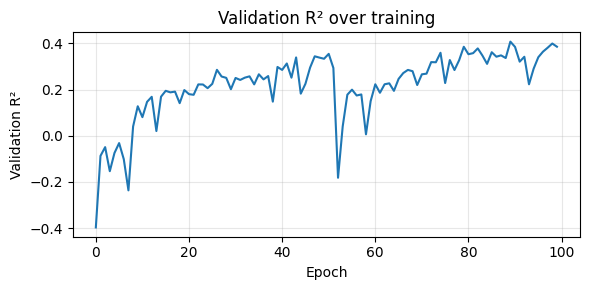

In [20]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(val_r2_history)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation R²")
ax.set_title("Validation R² over training")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

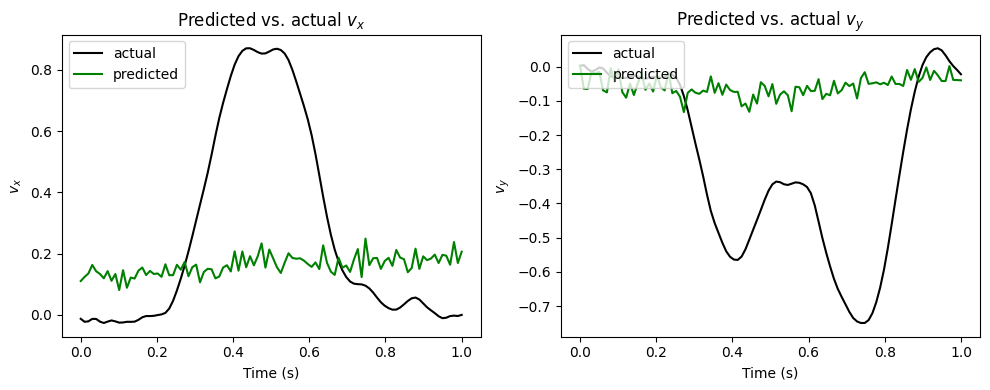

In [21]:
model.eval()
with torch.no_grad():
    X, Y = val_ds[next(iter(val_sampler))]
    pred = model(X.unsqueeze(0).to(device)).squeeze(0).cpu()

t = np.linspace(0, WINDOW_LENGTH, Y.shape[0])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
names = ["$v_x$", "$v_y$"]

for i, name in enumerate(names):
    axes[i].plot(t, Y[:, i].numpy(), label="actual", color="k")
    axes[i].plot(t, pred[:, i].numpy(), label="predicted", color="green")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel(name)
    axes[i].legend(loc="upper left")
axes[0].set_title("Predicted vs. actual $v_x$", usetex=False)
axes[1].set_title("Predicted vs. actual $v_y$", usetex=False)

plt.tight_layout()
plt.show()